In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
!pip install -q kagglehub

In [7]:
from datasets import load_dataset

dataset = load_dataset("jquigl/imdb-genres")

print(dataset)

README.md:   0%|          | 0.00/2.92k [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 54.3MB            

train.csv: downloading bytes:           |  0.00B            

validation.csv:   0%|          | 0.00/6.78M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/6.77M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/238256 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/29809 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29756 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description'],
        num_rows: 238256
    })
    validation: Dataset({
        features: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description'],
        num_rows: 29809
    })
    test: Dataset({
        features: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description'],
        num_rows: 29756
    })
})


In [8]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description'],
        num_rows: 238256
    })
    validation: Dataset({
        features: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description'],
        num_rows: 29809
    })
    test: Dataset({
        features: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description'],
        num_rows: 29756
    })
})


In [9]:
print(dataset["train"].column_names)

['movie title - year', 'genre', 'expanded-genres', 'rating', 'description']


In [10]:
print(dataset["train"][0])

{'movie title - year': 'Flaming Ears - 1992', 'genre': 'Fantasy', 'expanded-genres': 'Fantasy, Sci-Fi', 'rating': 6.0, 'description': 'Flaming Ears is a pop sci-fi lesbian fantasy feature set in the year 2700 in the fictive burned-out city of Asche. It follows the tangled lives of three women - Volley, Nun and Spy.'}


In [11]:
import pandas as pd

train_df = dataset["train"].to_pandas()

print("Dataset loaded successfully!")
print("Rows:", len(train_df))
print("Columns:", train_df.columns.tolist())

Dataset loaded successfully!
Rows: 238256
Columns: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description']


In [12]:
train_df.head()

,movie title - year,genre,expanded-genres,rating,description
0,Flaming Ears - 1992,Fantasy,"Fantasy, Sci-Fi",6.0,Flaming Ears is a pop sci-fi lesbian fantasy f...
1,Jeg elsker dig - 1957,Romance,"Comedy, Drama, Romance",5.8,Six people - three couples - meet at random at...
2,Povjerenje - 2021,Thriller,Thriller,NaN,"In a small unnamed town, in year 2025, Krsto w..."
3,Gulliver Returns - 2021,Fantasy,"Animation, Adventure, Family",4.4,The legendary Gulliver returns to the Kingdom ...
4,Prithvi Vallabh - 1924,Biography,"Biography, Drama, Romance",NaN,"Seminal silent historical film, the story feat..."


In [13]:
print("Missing values in each column:")
print(train_df.isnull().sum())

Missing values in each column:
movie title - year        0
genre                     0
expanded-genres           0
rating                69721
description               0
dtype: int64


In [14]:
print("Number of unique genres:", train_df["genre"].nunique())
print("\nGenres:")
print(train_df["genre"].value_counts())

Number of unique genres: 16

Genres:
genre
Thriller     36220
Romance      33704
Action       31156
Horror       24391
Crime        23368
Adventure    16234
Mystery      13159
Scifi        11363
Fantasy      11281
Family       10935
War           6415
History       5582
Biography     5438
Animation     5198
Sports        2997
Film-noir      815
Name: count, dtype: int64


In [15]:
print("Example movie descriptions:\n")

for i in range(3):
    print("Movie:", train_df.iloc[i]["movie title - year"])
    print("Genre:", train_df.iloc[i]["genre"])
    print("Description:", train_df.iloc[i]["description"])
    print("-" * 80)

Example movie descriptions:

Movie: Flaming Ears - 1992
Genre: Fantasy
Description: Flaming Ears is a pop sci-fi lesbian fantasy feature set in the year 2700 in the fictive burned-out city of Asche. It follows the tangled lives of three women - Volley, Nun and Spy.
--------------------------------------------------------------------------------
Movie: Jeg elsker dig - 1957
Genre: Romance
Description: Six people - three couples - meet at random at a dance restaurant in the Copenhagen nightlife. A marriage swindler and former actress, an elderly Supreme Court attorney with wife as well as...                See full summary »
--------------------------------------------------------------------------------
Movie: Povjerenje - 2021
Genre: Thriller
Description: In a small unnamed town, in year 2025, Krsto works for the Agency which offers hearings for other people's secrets, with warranty that those secrets shall never be spread. At one of the ...                See full summary »
----------

In [16]:
# Keep only rows that have a description and a genre
train_df = train_df.dropna(subset=["description", "genre"])

print("Dataset after removing missing values:")
print("Rows:", len(train_df))
print("Missing descriptions:", train_df["description"].isnull().sum())
print("Missing genres:", train_df["genre"].isnull().sum())

Dataset after removing missing values:
Rows: 238256
Missing descriptions: 0
Missing genres: 0


In [17]:
X = train_df["description"]
y = train_df["genre"]

print("Input (X): Movie descriptions")
print("Target (y): Movie genres")

print("\nNumber of descriptions:", len(X))
print("Number of genres:", len(y))

Input (X): Movie descriptions
Target (y): Movie genres

Number of descriptions: 238256
Number of genres: 238256


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 190604
Testing samples: 47652


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert movie descriptions into numerical features
tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF vectorization completed!")
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

TF-IDF vectorization completed!
Training matrix shape: (190604, 20000)
Testing matrix shape: (47652, 20000)


In [20]:
# Step 4: Train the Movie Genre Classification model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("Training the model... Please wait.")

# Create the model
model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

# Train using the training data
model.fit(X_train_tfidf, y_train)

print("Model training completed!")

# Predict genres for the testing data
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

Training the model... Please wait.
Model training completed!

Model Accuracy: 33.93%


In [21]:
# Step 5: Evaluate the model

print("MOVIE GENRE CLASSIFICATION REPORT")
print("=" * 40)

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

MOVIE GENRE CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Action       0.30      0.35      0.33      6231
   Adventure       0.21      0.15      0.18      3247
   Animation       0.36      0.13      0.19      1040
   Biography       0.44      0.29      0.35      1088
       Crime       0.32      0.28      0.30      4674
      Family       0.31      0.23      0.26      2187
     Fantasy       0.23      0.13      0.17      2256
   Film-noir       0.00      0.00      0.00       163
     History       0.26      0.14      0.18      1116
      Horror       0.41      0.47      0.44      4878
     Mystery       0.17      0.05      0.08      2632
     Romance       0.44      0.66      0.53      6741
       Scifi       0.34      0.29      0.32      2273
      Sports       0.44      0.32      0.37       599
    Thriller       0.27      0.35      0.31      7244
         War       0.41      0.40      0.40      1283

    accuracy                           0.34   

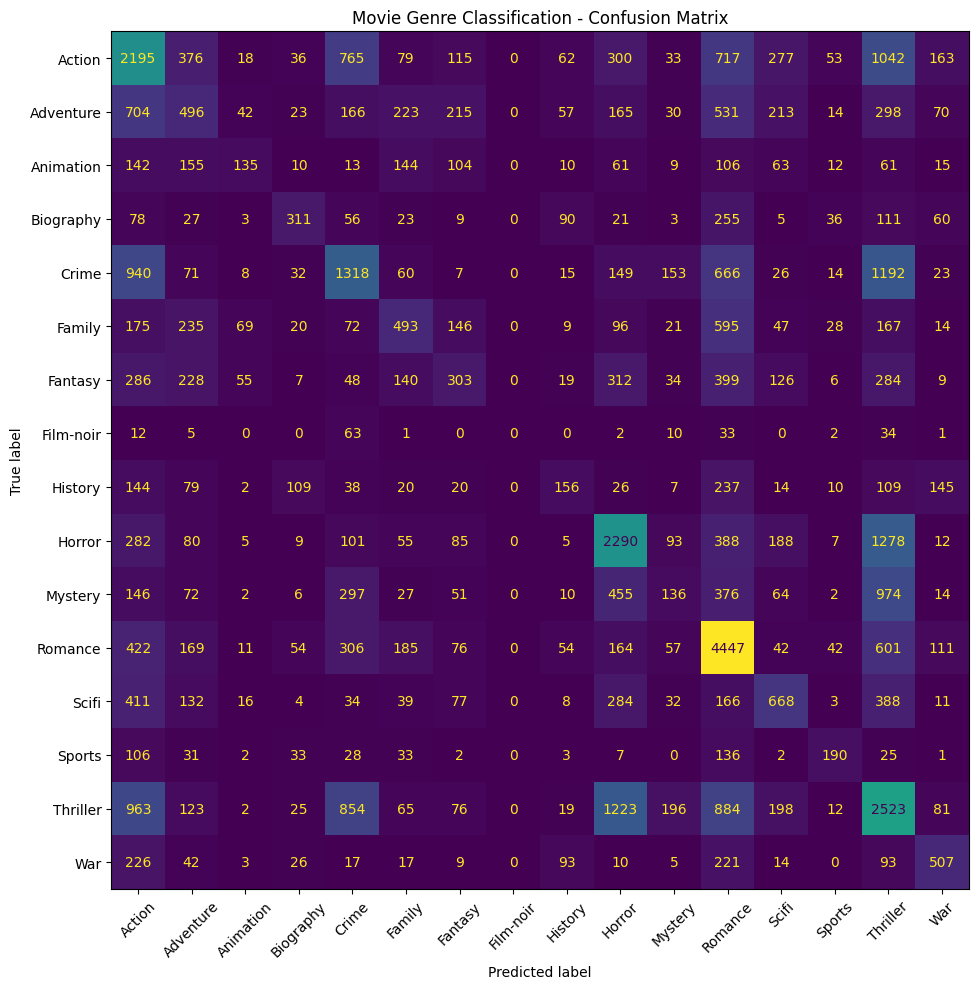

Confusion matrix saved successfully!


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

# Create the output folder
os.makedirs("output", exist_ok=True)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Display the graph
fig, ax = plt.subplots(figsize=(12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

display.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Movie Genre Classification - Confusion Matrix")
plt.tight_layout()

# Save the graph
plt.savefig("output/confusion_matrix.png", dpi=150)
plt.show()

print("Confusion matrix saved successfully!")

In [24]:
# Test the model with a new movie description

movie_description = """
A brave detective investigates a mysterious murder
and searches for clues to catch a dangerous criminal.
"""

# Convert the text using the same trained TF-IDF vectorizer
movie_features = tfidf.transform([movie_description])

# Predict the genre
predicted_genre = model.predict(movie_features)[0]

print("MOVIE GENRE CLASSIFICATION")
print("-" * 35)
print("Movie description:", movie_description.strip())
print("Predicted genre:", predicted_genre)

MOVIE GENRE CLASSIFICATION
-----------------------------------
Movie description: A brave detective investigates a mysterious murder
and searches for clues to catch a dangerous criminal.
Predicted genre: Crime


In [25]:
import os
import joblib

# Create folders for project files
os.makedirs("model", exist_ok=True)
os.makedirs("output", exist_ok=True)

# Save trained model and vectorizer
joblib.dump(model, "model/movie_genre_model.pkl")
joblib.dump(tfidf, "model/tfidf_vectorizer.pkl")

# Save prediction and evaluation results
with open("output/model_results.txt", "w") as f:
    f.write("Movie Genre Classification Results\n")
    f.write("=" * 35 + "\n")
    f.write(f"Accuracy: {accuracy * 100:.2f}%\n")
    f.write("Test samples: 47652\n")
    f.write("Predicted genre for sample movie: Crime\n")

print("Model saved successfully!")
print("Vectorizer saved successfully!")
print("Results saved successfully!")


Model saved successfully!
Vectorizer saved successfully!
Results saved successfully!


In [26]:
import os
import zipfile

# Files and folders to include
items = ["model", "output"]

with zipfile.ZipFile("movie_genre_results.zip", "w",
                     zipfile.ZIP_DEFLATED) as zipf:
    for item in items:
        if os.path.exists(item):
            if os.path.isfile(item):
                zipf.write(item)
            else:
                for root, dirs, files in os.walk(item):
                    for file in files:
                        path = os.path.join(root, file)
                        zipf.write(path)

print("Project results ZIP created successfully!")

Project results ZIP created successfully!


In [27]:
from google.colab import files

files.download("movie_genre_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import os

# Create project folders
folders = [
    "MOVIE-GENRE-CLASSIFICATION/data",
    "MOVIE-GENRE-CLASSIFICATION/src",
    "MOVIE-GENRE-CLASSIFICATION/output",
    "MOVIE-GENRE-CLASSIFICATION/screenshots",
    "MOVIE-GENRE-CLASSIFICATION/model"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [29]:
readme = """
# Movie Genre Classification

## Intern Name
Bhagya Sree Naragani

## Internship
CODETECH Internship

## Project Overview
This project predicts a movie genre from its description using
Natural Language Processing (NLP) and Machine Learning.

## Technologies Used
- Python
- Google Colab
- Scikit-learn
- TF-IDF Vectorization
- Logistic Regression

## Project Workflow
1. Load the movie dataset.
2. Process movie descriptions.
3. Convert text into numerical features using TF-IDF.
4. Train a Logistic Regression model.
5. Predict movie genres.
6. Evaluate the model using accuracy and a classification report.

## Model Result
Test accuracy: Approximately 34%

## Sample Prediction
Description: A brave detective investigates a mysterious murder
and searches for clues to catch a dangerous criminal.

Predicted Genre: Crime

## Note
The model's accuracy can be improved with further experimentation.
"""

import os

project_folder = "MOVIE-GENRE-CLASSIFICATION"
os.makedirs(project_folder, exist_ok=True)

with open(os.path.join(project_folder, "README.md"), "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [30]:
import os
import joblib

project_folder = "MOVIE-GENRE-CLASSIFICATION"
model_folder = os.path.join(project_folder, "model")
output_folder = os.path.join(project_folder, "output")

os.makedirs(model_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

# Save the trained model and TF-IDF vectorizer
joblib.dump(model, os.path.join(model_folder, "movie_genre_model.pkl"))
joblib.dump(tfidf, os.path.join(model_folder, "tfidf_vectorizer.pkl"))

# Save the evaluation results
with open(os.path.join(output_folder, "model_results.txt"), "w") as f:
    f.write("Movie Genre Classification Results\n")
    f.write("==================================\n")
    f.write(f"Accuracy: {accuracy * 100:.2f}%\n")
    f.write("Test samples: 47652\n")
    f.write("Sample prediction: Crime\n")

print("Model files and results saved successfully!")

Model files and results saved successfully!


In [31]:
import os
import zipfile

project_folder = "MOVIE-GENRE-CLASSIFICATION"
zip_name = "MOVIE-GENRE-CLASSIFICATION.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(project_folder):
        for file in files:
            full_path = os.path.join(root, file)
            zip_path = os.path.relpath(full_path, ".")
            zipf.write(full_path, zip_path)

print("Project ZIP created successfully!")
print("File:", zip_name)

Project ZIP created successfully!
File: MOVIE-GENRE-CLASSIFICATION.zip


In [32]:
from google.colab import files
files.download("MOVIE-GENRE-CLASSIFICATION.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>